# Rabbits and foxes

There are initially 400 rabbits and 200 foxes on a farm (but it could be two cell types in a 96 well plate or something, if you prefer bio-engineering analogies). Plot the concentration of foxes and rabbits as a function of time for a period of up to 600 days. The predator-prey relationships are given by the following set of coupled ordinary differential equations:

\begin{align}
\frac{dR}{dt} &= k_1 R - k_2 R F \tag{1}\\
\frac{dF}{dt} &= k_3 R F - k_4 F \tag{2}\\
\end{align}

* Constant for growth of rabbits $k_1 = 0.015$ day<sup>-1</sup>
* Constant for death of rabbits being eaten by foxes $k_2 = 0.00004$ day<sup>-1</sup> foxes<sup>-1</sup>
* Constant for growth of foxes after eating rabbits $k_3 = 0.0004$ day<sup>-1</sup> rabbits<sup>-1</sup>
* Constant for death of foxes $k_4 = 0.04$ day<sup>-1</sup>

*This problem is based on one from Chapter 1 of H. Scott Fogler's textbook "Essentials of Chemical Reaction Engineering".*


In [1]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

# Now let's try some Kinetic Monte Carlo

We wish to implement a Kinetic Monte Carlo algorithm to simulate the same situation. See https://en.wikipedia.org/wiki/Kinetic_Monte_Carlo for details.

We'll assume the numbers of rabbits and foxes (starting at 400 and 200) are actual rabbits and foxes, not "rabbit densities" for example, and so must always remain integers: you can't have half a rabbit or half a fox.

There are four events, with rates that are straightforward to calculate, so the rejection-free algorithm is suitable:
* `rabbit_birth = k1 * rabbits`
* `rabbit_death = k2 * rabbits * foxes`
* `fox_birth = k3 * rabbits * foxes`
* `fox_death = k4 * foxes`


Use a Kinetic Monte Carlo simulation(s) running for 600 days to determine
1. The expected location of the second peak in foxes (eg. 425 days, 2800 foxes), on occasions that there is one (eg. if there's a peak that's  >200 days and >100 foxes)
2. The interquartile range of the second peak in foxes (eg. 411-443 days, 2700-3120 foxes).
3. The probability that the foxes die out before 600 days are complete

Make sure you've done enough simulations to be suitably confident in your answers (given the precision you think appropriate).

# Your turn!

In [6]:
time = 0
rabbit = 400
fox = 200

times = [time]
rabbits = [rabbit]
foxes = [fox]

end_time = 600
k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04

while time < end_time:
    rate_rabbit_birth = k1 * rabbit
    rate_rabbit_death = k2 * rabbit * fox
    rate_fox_birth = k3 * rabbit * fox
    rate_fox_death = k4 * fox

    rates = np.array([rate_rabbit_birth, rate_rabbit_death, rate_fox_birth, rate_fox_death])
    
    cumulative_rates = np.cumsum(rates)
    total_rate = cumulative_rates[-1]

    u = np.random.uniform(0, 1)

    break

In [ ]:
for n in range(10):
    u = np.random.uniform(0, 1)
    for i, cum_rate in enumerate(cumulative_rates):
        if cum_rate / total_rate > u:
            event = i
            break
    print(u, event)

array([0.12195122, 0.06504065, 0.6504065 , 0.16260163])

Running test simulation...


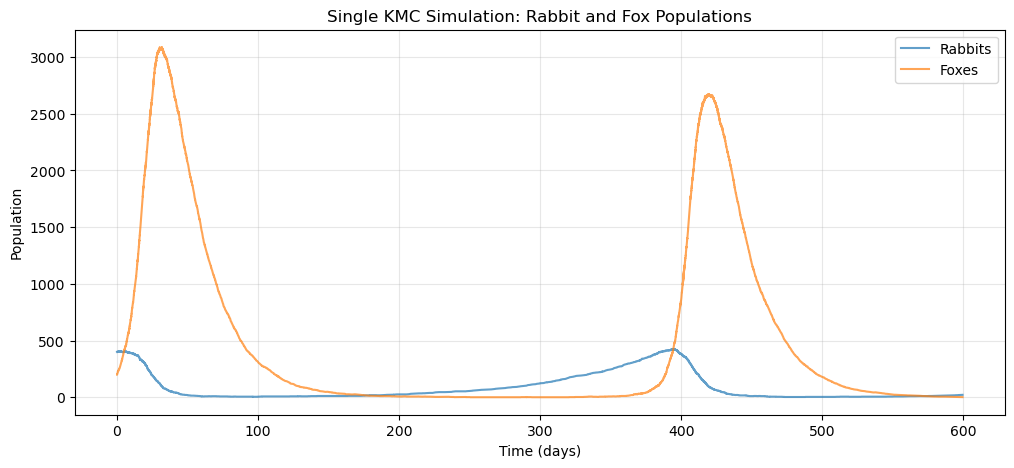

Simulation ended at t=599.30 days
Final populations: Rabbits=22, Foxes=2


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks

# Constants
k1 = 0.015
k2 = 0.00004
k3 = 0.0004
k4 = 0.04
end_time = 600

def run_kmc_simulation(initial_rabbits=400, initial_foxes=200, end_time=600, seed=None):
    """
    Run a single Kinetic Monte Carlo simulation of the rabbit-fox system.
    
    Returns:
        times: list of time points
        rabbits: list of rabbit populations
        foxes: list of fox populations
    """
    if seed is not None:
        np.random.seed(seed)
    
    time = 0
    rabbit = initial_rabbits
    fox = initial_foxes
    
    times = [time]
    rabbits = [rabbit]
    foxes = [fox]
    
    while time < end_time:
        # Calculate rates for all four events
        rate_rabbit_birth = k1 * rabbit
        rate_rabbit_death = k2 * rabbit * fox
        rate_fox_birth = k3 * rabbit * fox
        rate_fox_death = k4 * fox
        
        rates = np.array([rate_rabbit_birth, rate_rabbit_death, 
                         rate_fox_birth, rate_fox_death])
        total_rate = np.sum(rates)
        
        # If total rate is zero, nothing can happen (both populations extinct)
        if total_rate == 0:
            break
        
        # Calculate time to next event
        dt = np.random.exponential(1.0 / total_rate)
        time += dt
        
        if time > end_time:
            break
        
        # Select which event occurs
        cumulative_rates = np.cumsum(rates)
        u = np.random.uniform(0, total_rate)
        
        event = np.searchsorted(cumulative_rates, u)
        
        # Update populations based on event
        if event == 0:  # rabbit birth
            rabbit += 1
        elif event == 1:  # rabbit death
            rabbit -= 1
        elif event == 2:  # fox birth
            fox += 1
        elif event == 3:  # fox death
            fox -= 1
        
        # Ensure populations don't go negative (shouldn't happen, but safety check)
        rabbit = max(0, rabbit)
        fox = max(0, fox)
        
        # Record state
        times.append(time)
        rabbits.append(rabbit)
        foxes.append(fox)
    
    return times, rabbits, foxes

# Test with a single simulation
print("Running test simulation...")
times, rabbits, foxes = run_kmc_simulation()

plt.figure(figsize=(12, 5))
plt.plot(times, rabbits, label='Rabbits', alpha=0.7)
plt.plot(times, foxes, label='Foxes', alpha=0.7)
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title('Single KMC Simulation: Rabbit and Fox Populations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Simulation ended at t={times[-1]:.2f} days")
print(f"Final populations: Rabbits={rabbits[-1]}, Foxes={foxes[-1]}")

In [5]:
def find_second_peak(times, foxes, min_time=200, min_population=100):
    """
    Find the second peak in fox population.
    
    Returns:
        (peak_time, peak_population) or (None, None) if no valid second peak found
    """
    # Interpolate to regular grid for peak finding
    t_regular = np.linspace(0, max(times), 1000)
    fox_regular = np.interp(t_regular, times, foxes)
    
    # Find peaks with minimum prominence
    peaks, properties = find_peaks(fox_regular, prominence=50, distance=50)
    
    if len(peaks) == 0:
        return None, None
    
    # Filter peaks by time and population criteria
    valid_peaks = []
    for peak_idx in peaks:
        peak_time = t_regular[peak_idx]
        peak_pop = fox_regular[peak_idx]
        
        if peak_time > min_time and peak_pop > min_population:
            valid_peaks.append((peak_time, peak_pop))
    
    # Return the first valid peak (which would be the "second" peak chronologically)
    if len(valid_peaks) > 0:
        return valid_peaks[0]
    
    return None, None

# Test the peak finding
peak_time, peak_pop = find_second_peak(times, foxes)
if peak_time is not None:
    print(f"Second peak found at t={peak_time:.1f} days with {peak_pop:.0f} foxes")
else:
    print("No valid second peak found")

Second peak found at t=419.3 days with 2664 foxes


In [6]:
# Run multiple simulations
n_simulations = 1000
print(f"Running {n_simulations} simulations...")

second_peak_times = []
second_peak_populations = []
fox_extinction_count = 0

for i in range(n_simulations):
    if (i + 1) % 100 == 0:
        print(f"Completed {i + 1}/{n_simulations} simulations")
    
    times, rabbits, foxes = run_kmc_simulation()
    
    # Check if foxes died out
    if foxes[-1] == 0:
        fox_extinction_count += 1
    
    # Find second peak
    peak_time, peak_pop = find_second_peak(times, foxes)
    
    if peak_time is not None:
        second_peak_times.append(peak_time)
        second_peak_populations.append(peak_pop)

print(f"\nSimulations complete!")
print(f"Valid second peaks found: {len(second_peak_times)}/{n_simulations}")
print(f"Fox extinctions: {fox_extinction_count}/{n_simulations}")

Running 1000 simulations...
Completed 100/1000 simulations
Completed 200/1000 simulations
Completed 300/1000 simulations
Completed 400/1000 simulations
Completed 500/1000 simulations
Completed 600/1000 simulations
Completed 700/1000 simulations
Completed 800/1000 simulations
Completed 900/1000 simulations
Completed 1000/1000 simulations

Simulations complete!
Valid second peaks found: 347/1000
Fox extinctions: 671/1000


In [9]:
# Analyze results
if len(second_peak_times) > 0:
    # Convert to numpy arrays
    peak_times_array = np.array(second_peak_times)
    peak_pops_array = np.array(second_peak_populations)
    
    # Calculate statistics
    mean_peak_time = np.mean(peak_times_array)
    mean_peak_pop = np.mean(peak_pops_array)
    
    # Calculate interquartile ranges
    q25_time, q75_time = np.percentile(peak_times_array, [25, 75])
    q25_pop, q75_pop = np.percentile(peak_pops_array, [25, 75])
    
    print("\n" + "="*60)
    print("RESULTS:")
    print("="*60)
    print(f"\n1. Expected location of second peak in foxes:")
    print(f"   Time: {mean_peak_time:.1f} days")
    print(f"   Population: {mean_peak_pop:.0f} foxes")
    
    print(f"\n2. Interquartile range of second peak:")
    print(f"   Time: {q25_time:.1f} - {q75_time:.1f} days")
    print(f"   Population: {q25_pop:.0f} - {q75_pop:.0f} foxes")
    
    print(f"\n3. Probability that foxes die out before 600 days:")
    extinction_probability = fox_extinction_count / n_simulations
    print(f"   {extinction_probability:.3f} ({fox_extinction_count}/{n_simulations})")
    
    # Calculate confidence intervals (95%)
    stderr_time = np.std(peak_times_array) / np.sqrt(len(peak_times_array))
    stderr_pop = np.std(peak_pops_array) / np.sqrt(len(peak_pops_array))
    
    print(f"\n95% Confidence intervals:")
    print(f"   Peak time: {mean_peak_time:.1f} ± {1.96*stderr_time:.1f} days")
    print(f"   Peak population: {mean_peak_pop:.0f} ± {1.96*stderr_pop:.0f} foxes")
    
    # Standard error for extinction probability (binomial)
    stderr_extinction = np.sqrt(extinction_probability * (1 - extinction_probability) / n_simulations)
    print(f"   Extinction probability: {extinction_probability:.3f} ± {1.96*stderr_extinction:.3f}")
    print("="*60)
    
else:
    print("No valid second peaks found in any simulation!")


RESULTS:

1. Expected location of second peak in foxes:
   Time: 401.4 days
   Population: 2389 foxes

2. Interquartile range of second peak:
   Time: 380.3 - 420.3 days
   Population: 1919 - 2757 foxes

3. Probability that foxes die out before 600 days:
   0.671 (671/1000)

95% Confidence intervals:
   Peak time: 401.4 ± 3.3 days
   Peak population: 2389 ± 67 foxes
   Extinction probability: 0.671 ± 0.029


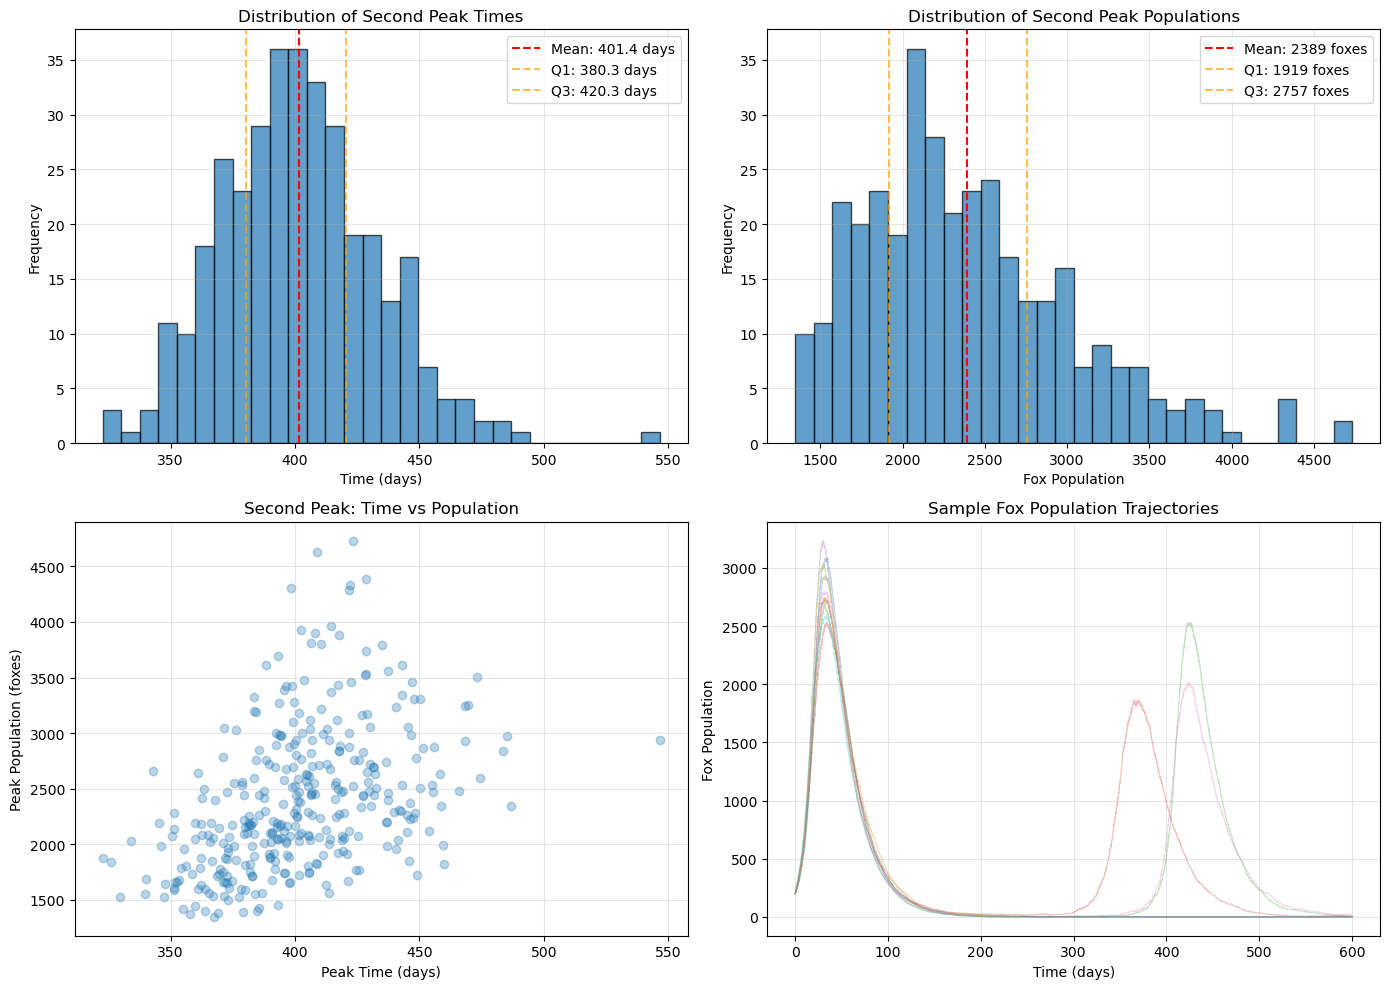

In [8]:
# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of peak times
if len(second_peak_times) > 0:
    axes[0, 0].hist(second_peak_times, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(mean_peak_time, color='red', linestyle='--', 
                       label=f'Mean: {mean_peak_time:.1f} days')
    axes[0, 0].axvline(q25_time, color='orange', linestyle='--', alpha=0.7,
                       label=f'Q1: {q25_time:.1f} days')
    axes[0, 0].axvline(q75_time, color='orange', linestyle='--', alpha=0.7,
                       label=f'Q3: {q75_time:.1f} days')
    axes[0, 0].set_xlabel('Time (days)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Second Peak Times')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram of peak populations
if len(second_peak_populations) > 0:
    axes[0, 1].hist(second_peak_populations, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(mean_peak_pop, color='red', linestyle='--',
                       label=f'Mean: {mean_peak_pop:.0f} foxes')
    axes[0, 1].axvline(q25_pop, color='orange', linestyle='--', alpha=0.7,
                       label=f'Q1: {q25_pop:.0f} foxes')
    axes[0, 1].axvline(q75_pop, color='orange', linestyle='--', alpha=0.7,
                       label=f'Q3: {q75_pop:.0f} foxes')
    axes[0, 1].set_xlabel('Fox Population')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Second Peak Populations')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter plot of peak time vs population
if len(second_peak_times) > 0:
    axes[1, 0].scatter(second_peak_times, second_peak_populations, alpha=0.3)
    axes[1, 0].set_xlabel('Peak Time (days)')
    axes[1, 0].set_ylabel('Peak Population (foxes)')
    axes[1, 0].set_title('Second Peak: Time vs Population')
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Sample trajectories
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Fox Population')
axes[1, 1].set_title('Sample Fox Population Trajectories')
axes[1, 1].grid(True, alpha=0.3)

# Plot a few sample trajectories
for i in range(min(10, n_simulations)):
    times_sample, rabbits_sample, foxes_sample = run_kmc_simulation(seed=i*100)
    axes[1, 1].plot(times_sample, foxes_sample, alpha=0.3, linewidth=0.8)

plt.tight_layout()
plt.show()